# Project - Airline AI Assistant

We'll now bring together what we've learned to make an AI Customer Support assistant for an Airline

In [1]:
# imports

import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# # Initialization

# load_dotenv(override=True)

# openai_api_key = os.getenv('OPENAI_API_KEY')
# if openai_api_key:
#     print(f"OpenAI API Key exists and begins {openai_api_key[:8]}")
# else:
#     print("OpenAI API Key not set")
    
# MODEL = "gpt-4.1-mini"
# openai = OpenAI()

# DB = "prices.db"


### Writing code For GROQ

import os
from dotenv import load_dotenv
from groq import Groq  

load_dotenv(override=True)

groq_api_key = os.getenv('GROQ_API_KEY')

if groq_api_key:
    print(f"Groq API Key exists and begins {groq_api_key[:8]}")
else:
    print("Groq API Key not set")
    
MODEL = "llama-3.3-70b-versatile"
client = Groq()

DB = "prices.db"


Groq API Key exists and begins gsk_TGwM


In [3]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [4]:
def get_ticket_price(city):
    print(f"DATABASE TOOL CALLED: Getting price for {city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {city} is ${result[0]}" if result else "No price data available for this city"

In [5]:
get_ticket_price("Paris")

DATABASE TOOL CALLED: Getting price for Paris


'Ticket price to Paris is $899.0'

In [6]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}
tools = [{"type": "function", "function": price_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}}]

In [7]:

# def chat(message, history):
#     history = [{"role": h["role"], "content": h["content"]} for h in history]
#     messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
#     response = openai.chat.completions.create(model=MODEL, messages=messages)
#     return response.choices[0].message.content

# gr.ChatInterface(fn=chat, type="messages").launch()


### GROQ


import os
from dotenv import load_dotenv
from groq import Groq
import gradio as gr

load_dotenv(override=True)

MODEL = "llama-3.3-70b-versatile"
client = Groq()

system_message = "You are a helpful assistant."

def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = client.chat.completions.create(model=MODEL, messages=messages)
    return response.choices[0].message.content

gr.ChatInterface(fn=chat).launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [8]:
# def chat(message, history):
#     history = [{"role":h["role"], "content":h["content"]} for h in history]
#     messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
#     response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

#     while response.choices[0].finish_reason=="tool_calls":
#         message = response.choices[0].message
#         responses = handle_tool_calls(message)
#         messages.append(message)
#         messages.extend(responses)
#         response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
#     return response.choices[0].message.content


### GROQ


import os
from dotenv import load_dotenv
from groq import Groq
import gradio as gr

load_dotenv(override=True)

MODEL = "llama-3.3-70b-versatile"
client = Groq()

def chat(message, history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history + [{"role": "user", "content": message}]
    response = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)

    while response.choices[0].finish_reason == "tool_calls":
        message = response.choices[0].message
        responses = handle_tool_calls(message)
        messages.append(message)
        messages.extend(responses)
        response = client.chat.completions.create(model=MODEL, messages=messages, tools=tools)
    
    return response.choices[0].message.content

gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


In [9]:
def handle_tool_calls(message):
    responses = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses

In [10]:
gr.ChatInterface(fn=chat).launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


## A bit more about what Gradio actually does:

1. Gradio constructs a frontend Svelte app based on our Python description of the UI
2. Gradio starts a server built upon the Starlette web framework listening on a free port that serves this React app
3. Gradio creates backend routes for our callbacks, like chat(), which calls our functions

And of course when Gradio generates the frontend app, it ensures that the the Submit button calls the right backend route.

That's it!

It's simple, and it has a result that feels magical.

# Let's go multi-modal!!

We can use DALL-E-3, the image generation model behind GPT-4o, to make us some images

Let's put this in a function called artist.

### Price alert: each time I generate an image it costs about 4 cents - don't go crazy with images!

In [11]:
# Some imports for handling images

import base64
from io import BytesIO
from PIL import Image

In [ ]:
### Image Generation using DALL-E-3

# def artist(city):
#     image_response = openai.images.generate(
#             model="dall-e-3",
#             prompt=f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style",
#             size="1024x1024",
#             n=1,
#             response_format="b64_json",
#         )
#     image_base64 = image_response.data[0].b64_json
#     image_data = base64.b64decode(image_base64)
#     return Image.open(BytesIO(image_data))


### Image Generation using FLUX

import requests
from io import BytesIO
from PIL import Image
import urllib.parse

def artist(city):
    try:
        encoded_prompt = urllib.parse.quote(f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style")
        
        url = f"https://image.pollinations.ai/p/{encoded_prompt}?width=1024&height=1024&model=flux"
        
        response = requests.get(url, timeout=30)
        if response.status_code == 200:
            return Image.open(BytesIO(response.content))
        else:
            print(f"Pollinations Error Status: {response.status_code}")
            return None
    except Exception as e:
        print(f"Image Generation Error: {e}")
        return None

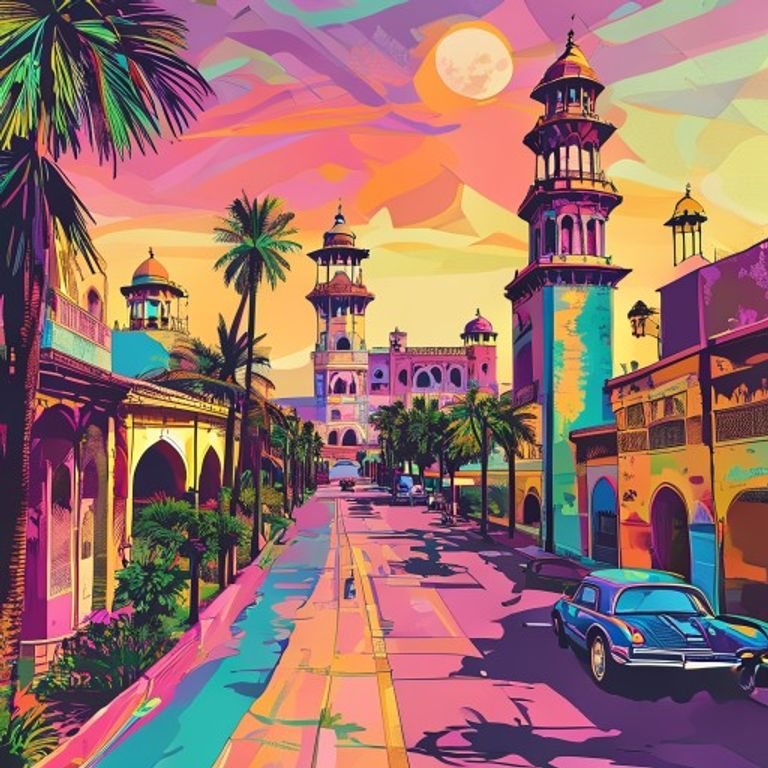

In [21]:
image = artist("Lahore City")
display(image)

In [ ]:
# def talker(message):
#     response = openai.audio.speech.create(
#       model="gpt-4o-mini-tts",
#       voice="onyx",    # Also, try replacing onyx with alloy or coral
#       input=message
#     )
#     return response.content


### USING GEMINI FOR VOICES

import os
from google import genai
from google.genai import types

def talker(message):
    try:
        client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
        
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=message,
            config=types.GenerateContentConfig(
                response_modalities=["AUDIO"],
                speech_config=types.SpeechConfig(
                    voice_config=types.VoiceConfig(
                        prebuilt_voice_config=types.PrebuiltVoiceConfig(
                            voice_name="Puck" # You can use "Puck", "Charon", "Kore", "Fenrir", or "Aoede" voices.
                        )
                    )
                )
            )
        )
        
        if response.candidates and response.candidates[0].content.parts:
            for part in response.candidates[0].content.parts:
                if part.inline_data:
                    return part.inline_data.data
        return b""
    except Exception as e:
        print(f"Talker Error: {e}")
        return b""


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Let's bring this home:

1. A multi-modal AI assistant with image and audio generation
2. Tool callling with database lookup
3. A step towards an Agentic workflow


In [ ]:
# def chat(history):
#     history = [{"role":h["role"], "content":h["content"]} for h in history]
#     messages = [{"role": "system", "content": system_message}] + history
#     response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)
#     cities = []
#     image = None

#     while response.choices[0].finish_reason=="tool_calls":
#         message = response.choices[0].message
#         responses, cities = handle_tool_calls_and_return_cities(message)
#         messages.append(message)
#         messages.extend(responses)
#         response = openai.chat.completions.create(model=MODEL, messages=messages, tools=tools)

#     reply = response.choices[0].message.content
#     history += [{"role":"assistant", "content":reply}]

#     voice = talker(reply)

#     if cities:
#         image = artist(cities[0])
    
#     return history, voice, image




### USING GROQ

def chat(history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    
    try:
        response = groq_client.chat.completions.create(
            model="llama3-groq-70b-8192-tool-use-preview", 
            messages=messages, 
            tools=tools
        )
        cities = []
        image = None

        while response.choices[0].finish_reason == "tool_calls":
            message = response.choices[0].message
            responses, cities_extracted = handle_tool_calls_and_return_cities(message)
            
            if cities_extracted:
                cities.extend(cities_extracted)
                
            messages.append({
                "role": "assistant",
                "tool_calls": message.tool_calls
            })
            messages.extend(responses)
            
            response = groq_client.chat.completions.create(
                model="llama3-groq-70b-8192-tool-use-preview", 
                messages=messages, 
                tools=tools
            )

        reply = response.choices[0].message.content if response.choices[0].message.content else "Processing done."
        history.append({"role": "assistant", "content": reply})

        voice = talker(reply)
        if cities:
            image = artist(cities[0])
            
    except Exception as e:
        print(f"Chat Error: {e}")
        reply = f"Sorry, I encountered an error: {str(e)}"
        history.append({"role": "assistant", "content": reply})
        voice = b""
        image = None
    
    return history, voice, image


In [ ]:
def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            arguments = json.loads(tool_call.function.arguments)
            city = arguments.get('destination_city')
            cities.append(city)
            price_details = get_ticket_price(city)
            responses.append({
                "role": "tool",
                "content": price_details,
                "tool_call_id": tool_call.id
            })
    return responses, cities




## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks

In [31]:
def put_message_in_chatbot(message, history):
    if history is None:
        history = []
    history.append({"role": "user", "content": message})
    return "", history

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=500)
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

    message.submit(
        put_message_in_chatbot, 
        inputs=[message, chatbot], 
        outputs=[message, chatbot]
    ).then(
        chat, 
        inputs=chatbot, 
        outputs=[chatbot, audio_output, image_output]
    )

if __name__ == "__main__":
    ui.launch(inbrowser=True, auth=("sam", "sha"))

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


In [ ]:
### Complete Code in a Single CELL

import os
import json
import urllib.parse
import requests
from io import BytesIO
from PIL import Image
import gradio as gr
from google import genai
from google.genai import types
from groq import Groq

os.environ["GROQ_API_KEY"] = "your_groq_api_key_here"
os.environ["GEMINI_API_KEY"] = "your_gemini_api_key_here"

MODEL = "llama-3.3-70b-versatile"
system_message = "You are a helpful airline assistant. Keep answers brief."

tools = [
    {
        "type": "function",
        "function": {
            "name": "get_ticket_price",
            "description": "Get the ticket price for a destination city.",
            "parameters": {
                "type": "object",
                "properties": {
                    "destination_city": {
                        "type": "string",
                        "description": "The city to check the ticket price for, e.g., London, Paris."
                    }
                },
                "required": ["destination_city"]
            }
        }
    }
]

groq_client = Groq(api_key=os.getenv("GROQ_API_KEY"))

def get_ticket_price(city):
    prices = {"london": "$799", "paris": "$899", "tokyo": "$1420"}
    price = prices.get(city.lower(), "$500")
    return f"The return ticket price for {city} is {price}."

def artist(city):
    try:
        encoded_prompt = urllib.parse.quote(f"An image representing a vacation in {city}, showing tourist spots, vibrant pop-art style")
        url = f"https://image.pollinations.ai/p/{encoded_prompt}?width=1024&height=1024&model=flux"
        response = requests.get(url, timeout=20)
        if response.status_code == 200:
            return Image.open(BytesIO(response.content))
    except Exception as e:
        print(f"Artist Error: {e}")
    return None

def talker(message):
    try:
        client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=message,
            config=types.GenerateContentConfig(
                response_modalities=["AUDIO"],
                speech_config=types.SpeechConfig(
                    voice_config=types.VoiceConfig(
                        prebuilt_voice_config=types.PrebuiltVoiceConfig(voice_name="Puck")
                    )
                )
            )
        )
        if response.candidates and response.candidates[0].content.parts:
            for part in response.candidates[0].content.parts:
                if part.inline_data:
                    return part.inline_data.data
    except Exception as e:
        print(f"Talker Error: {e}")
    return b""

def handle_tool_calls_and_return_cities(message):
    responses = []
    cities = []
    if not message.tool_calls:
        return responses, cities
    for tool_call in message.tool_calls:
        if tool_call.function.name == "get_ticket_price":
            try:
                if isinstance(tool_call.function.arguments, dict):
                    arguments = tool_call.function.arguments
                else:
                    arguments = json.loads(tool_call.function.arguments)
                city = arguments.get('destination_city')
                if city:
                    cities.append(city)
                    price_details = get_ticket_price(city)
                else:
                    price_details = "Error: City missing."
                responses.append({
                    "role": "tool",
                    "content": price_details,
                    "tool_call_id": tool_call.id
                })
            except Exception as e:
                print(f"Tool Error: {e}")
    return responses, cities

def chat(history):
    history = [{"role": h["role"], "content": h["content"]} for h in history]
    messages = [{"role": "system", "content": system_message}] + history
    cities = []
    image = None
    voice = b""

    try:
        response = groq_client.chat.completions.create(
            model=MODEL, 
            messages=messages, 
            tools=tools
        )

        while response.choices[0].finish_reason == "tool_calls":
            message = response.choices[0].message
            responses, cities_extracted = handle_tool_calls_and_return_cities(message)
            if cities_extracted:
                cities.extend(cities_extracted)
            messages.append({
                "role": "assistant",
                "tool_calls": message.tool_calls
            })
            messages.extend(responses)
            response = groq_client.chat.completions.create(
                model=MODEL, 
                messages=messages, 
                tools=tools
            )

        reply = response.choices[0].message.content if response.choices[0].message.content else "Processing..."
        history.append({"role": "assistant", "content": reply})
        voice = talker(reply)
        if cities:
            image = artist(cities[0])

    except Exception as e:
        print(f"Chat Loop Error: {e}")
        history.append({"role": "assistant", "content": f"Error: {str(e)}"})

    return history, voice, image

def put_message_in_chatbot(message, history):
    if history is None:
        history = []
    history.append({"role": "user", "content": message})
    return "", history

with gr.Blocks() as ui:
    with gr.Row():
        chatbot = gr.Chatbot(height=450)
        image_output = gr.Image(height=450, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

    message.submit(
        put_message_in_chatbot, 
        inputs=[message, chatbot], 
        outputs=[message, chatbot]
    ).then(
        chat, 
        inputs=chatbot, 
        outputs=[chatbot, audio_output, image_output]
    )

ui.launch(inbrowser=True)

* Running on local URL:  http://127.0.0.1:7870
* To create a public link, set `share=True` in `launch()`.
